(zeotropic_heat_pump_label)=

# Zeotropic mixtures in a heat pump

This example shows how to model a heat pump using a zeotropic fluid mixture. It
is integrated in the `ModelTemplate` class and uses `SectionedHeatExchanger` 
to inspect the temperature glide in TQ diagrams. Furthermore, different 
compositions are evaluated, and the results of a REFPROP based and a thermopack
based model are compared:

- **CoolProp's REFPROP back end** requires a REFPROP license
- **thermopack** is a free alternative, install it with `uv add thermopack` or
  `pip install thermopack`

For a general comparison of the two fluid property back ends see
{ref}`this notebook <fluid_property_backends_label>`.

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from tespy.components import Compressor
from tespy.components import CycleCloser
from tespy.components import SectionedHeatExchanger
from tespy.components import Sink
from tespy.components import Source
from tespy.components import Valve
from tespy.connections import Connection
from tespy.models.template import ModelTemplate
from tespy.networks import Network
from tespy.tools.fluid_properties.wrappers import CoolPropWrapper
from tespy.tools.fluid_properties.wrappers import ThermopackWrapper

import CoolProp.CoolProp as CP

try:
    CP.AbstractState("REFPROP", "Propane")
    ENGINES = ["thermopack", "refprop"]
except ValueError:
    print("REFPROP is not available on this machine, skipping it.")
    ENGINES = ["thermopack"]

## Heat pump model

The advantage of zeotropic fluid mixtures is, that the temperature glide (the
difference between dew line and bubble line temperature at constant pressure)
can be exploited to reduce the temperature difference between the condensing or
evaporating working fluid and the heat source or heat sink fluid respectively.
This reduces the entropy production an may thus improve the COP of the system
compared to a pure fluid.

A `ModelTemplate` subclass `ZeotropicHeatPumpModel` is implemented using water 
on the heat source and heat sink sides. The fluid composition and the fluid
property engine can be selected manually to enable running the model with
thermopack or with CoolProp's REFPROP back end.

Note the following addition for the `thermopack` engine: The wrapper limits are
restricted to the operating range of the model through `fluid_wrapper_kwargs`.
Thermopack's default temperature minimum of 80 K lies in a region where its
flash routines are unstable.

In [ ]:
BLENDS = {
    "propane/isobutane": {
        "thermopack": ("C3", "IC4"),
        "refprop": ("Propane", "Isobutane"),
    },
    "propane/pentane": {
        "thermopack": ("C3", "NC5"),
        "refprop": ("Propane", "n-Pentane"),
    },
}


class ZeotropicHeatPumpModel(ModelTemplate):
    """Heat pump with a zeotropic hydrocarbon working fluid."""

    def __init__(
            self, fraction=0.5, engine="thermopack", back_end="PR",
            blend="propane/isobutane"
    ) -> None:
        self.fraction = fraction
        self.engine = engine
        self.back_end = back_end if engine == "thermopack" else "REFPROP"
        self.blend = blend
        super().__init__()

    def _working_fluid(self) -> str:
        first, second = BLENDS[self.blend][self.engine]
        if self.fraction == 0:
            return second
        elif self.fraction == 1:
            return first
        return f"{first}[{self.fraction}]&{second}[{1 - self.fraction}]|molar"

    def _create_network(self) -> None:
        self.nw = Network()
        self.nw.units.set_defaults(**{
            "pressure": "bar",
            "pressure_difference": "bar",
            "enthalpy": "kJ/kg",
            "temperature": "degC",
            "power": "kW",
            "heat": "kW",
            "mass_flow": "kg/s",
        })
        self.nw.iterinfo = False

        cycle_closer = CycleCloser("cycle closer")
        compressor = Compressor("compressor")
        condenser = SectionedHeatExchanger("condenser")
        valve = Valve("valve")
        evaporator = SectionedHeatExchanger("evaporator")

        heating_source = Source("heating water source")
        heating_sink = Sink("heating water sink")
        geo_source = Source("source water source")
        geo_sink = Sink("source water sink")

        c01 = Connection(cycle_closer, "out1", compressor, "in1", label="01")
        c02 = Connection(compressor, "out1", condenser, "in1", label="02")
        c03 = Connection(condenser, "out1", valve, "in1", label="03")
        c04 = Connection(valve, "out1", evaporator, "in2", label="04")
        c05 = Connection(evaporator, "out2", cycle_closer, "in1", label="05")

        c11 = Connection(heating_source, "out1", condenser, "in2", label="11")
        c12 = Connection(condenser, "out2", heating_sink, "in1", label="12")

        c21 = Connection(geo_source, "out1", evaporator, "in1", label="21")
        c22 = Connection(evaporator, "out1", geo_sink, "in1", label="22")

        self.nw.add_conns(c01, c02, c03, c04, c05, c11, c12, c21, c22)

        fluid = self._working_fluid()
        engine_kwargs = {}
        if self.engine == "thermopack":
            wrapper_class = ThermopackWrapper
            engine_kwargs["fluid_wrapper_kwargs"] = {
                fluid: {"T_min": 233.15, "T_max": 500, "p_min": 1e4}
            }
        else:
            wrapper_class = CoolPropWrapper

        c01.set_attr(
            fluid={f"{self.back_end}::{fluid}": 1},
            fluid_engines={fluid: wrapper_class},
            td_dew=5, **engine_kwargs
        )
        c03.set_attr(td_bubble=2)

        c11.set_attr(fluid={"Water": 1}, T=30, p=3)
        c12.set_attr(T=50)

        c21.set_attr(fluid={"Water": 1}, T=15, p=3)
        c22.set_attr(T=10)

        compressor.set_attr(eta_s=0.8)
        condenser.set_attr(dp1=0, dp2=0, td_pinch=3, Q=-100)
        evaporator.set_attr(dp1=0, dp2=0, td_pinch=3)

    def _parameter_lookup(self) -> dict:
        return {
            "T heating in": ["Connections", "11", "T"],
            "T heating out": ["Connections", "12", "T"],
            "T source in": ["Connections", "21", "T"],
            "T source out": ["Connections", "22", "T"],
            "superheating": ["Connections", "01", "td_dew"],
            "subcooling": ["Connections", "03", "td_bubble"],
            "eta_s compressor": ["Components", "compressor", "eta_s"],
            "td pinch condenser": ["Components", "condenser", "td_pinch"],
            "td pinch evaporator": ["Components", "evaporator", "td_pinch"],
            "heating capacity": ["Components", "condenser", "Q"],
            "compressor power": ["Components", "compressor", "P"],
            "p evaporation": ["Connections", "05", "p"],
            "p condensation": ["Connections", "02", "p"],
            "COP": {"get": self._calc_cop},
            "volumetric heating capacity": {"get": self._calc_vhc},
            "glide condenser": {"get": self._calc_glide},
        }

    def _calc_cop(self) -> float:
        return abs(
            self.nw.get_comp("condenser").Q.val_SI
        ) / self.nw.get_comp("compressor").P.val_SI

    def _calc_vhc(self) -> float:
        # heat delivered per unit of volume flow at the compressor inlet
        # (volumetric heating capacity HVC) in kJ/m3
        return abs(
            self.nw.get_comp("condenser").Q.val_SI
        ) / self.nw.get_conn("01").v.val_SI / 1e3

    def _calc_glide(self) -> float:
        c03 = self.nw.get_conn("03")
        return c03.T_dew.val_SI - c03.T_bubble.val_SI

    def solve_model(self, **kwargs) -> None:
        self.solve_model_design(**kwargs)

In [3]:
model = ZeotropicHeatPumpModel(fraction=0.5)
model.solve_model()
model.nw.assert_convergence()
model.get_results([
    "COP", "volumetric heating capacity", "glide condenser",
    "p evaporation", "p condensation"
])

{'COP': 5.046708577260929,
 'volumetric heating capacity': 2370.5643209153664,
 'glide condenser': 6.575896771585121,
 'p evaporation': 2.9853744130205486,
 'p condensation': 10.310099188864099}

## Temperature glide in the TQ diagram

You can see the glide of the mixture in the TQ diagrams of the two heat
exchangers. In the evaporator a near parallel profile is observed, in the 
condenser the glide cannot match the steep temperature increase of the water
but still siginificantly reduces the temperature difference between the two
fluids.

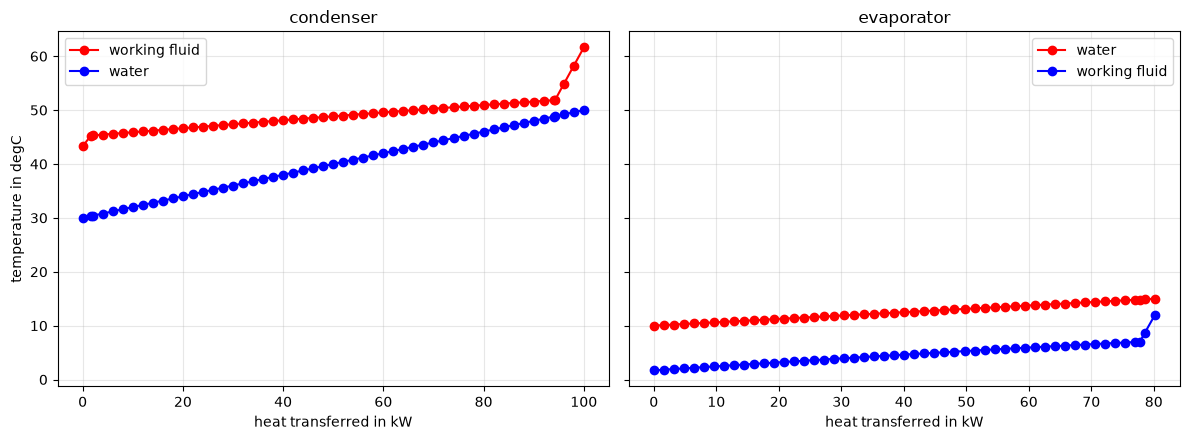

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

model.plot_QT_diagram_matplotlib("condenser", ax=axes[0])
model.plot_QT_diagram_matplotlib("evaporator", ax=axes[1])

axes[0].set_title("condenser")
axes[0].legend(["working fluid", "water"])
axes[1].set_title("evaporator")
axes[1].legend(["water", "working fluid"])

for ax in axes:
    ax.grid(alpha=0.3)

plt.tight_layout()

## Mixture composition sensitivity

We can create a single model for each working fluid composition from a molar
propane fraction of 0 % to 100 % (pure isobutane to pure propane). In the 
analysis we track the COP and the volumetric heating capacity VHC as calculated
with either REFPROP or thermopack.

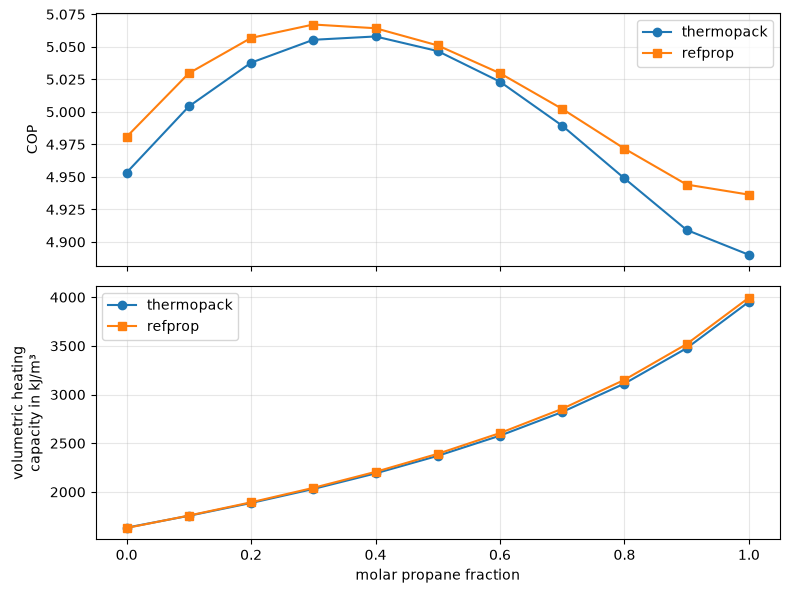

In [5]:
def sweep_composition(blend):
    records = {}
    for engine in ENGINES:
        for fraction in np.linspace(0, 1, 11).round(1):
            m = ZeotropicHeatPumpModel(
                fraction=float(fraction), engine=engine, blend=blend
            )
            start = time.perf_counter()
            m.solve_model()
            elapsed = time.perf_counter() - start
            m.nw.assert_convergence()
            records[(engine, fraction)] = {
                **m.get_results([
                    "COP", "volumetric heating capacity", "glide condenser"
                ]),
                "solve time / s": elapsed,
            }
    sweep = pd.DataFrame(records).T
    sweep.index.names = ["engine", "fraction"]
    return sweep


def plot_sweep(sweep, xlabel):
    fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
    colors = {"thermopack": "tab:blue", "refprop": "tab:orange"}
    markers = {"thermopack": "o", "refprop": "s"}
    for engine in sweep.index.get_level_values("engine").unique():
        data = sweep.loc[engine]
        axes[0].plot(
            data.index, data["COP"], marker=markers[engine],
            color=colors[engine], label=engine
        )
        axes[1].plot(
            data.index, data["volumetric heating capacity"],
            marker=markers[engine], color=colors[engine], label=engine
        )
    axes[0].set_ylabel("COP")
    axes[1].set_ylabel("volumetric heating\ncapacity in kJ/m³")
    axes[1].set_xlabel(xlabel)
    for ax in axes:
        ax.grid(alpha=0.3)
        ax.legend()
    plt.tight_layout()
    return fig, axes


sweep = sweep_composition("propane/isobutane")
_ = plot_sweep(sweep, "molar propane fraction")

The results show an optimal COP at about 30 % to 40 % molar propane fraction
and both engines calculate similar results. The VHC grows consistently and is
maximal with pure propane.

## Differences in results and performance

The deviation of the cubic equation of state from the reference and the
difference in solve time can be quantified:

In [6]:
if "refprop" in ENGINES:
    tp = sweep.loc["thermopack"]
    rp = sweep.loc["refprop"]
    comparison = pd.Series({
        "COP, max relative deviation":
            f"{(tp['COP'] / rp['COP'] - 1).abs().max():.2%}",
        "volumetric heating capacity, max relative deviation":
            f"{(tp['volumetric heating capacity'] / rp['volumetric heating capacity'] - 1).abs().max():.2%}",
        "condenser glide, max absolute deviation":
            f"{(tp['glide condenser'] - rp['glide condenser']).abs().max():.2f} K",
        "mean solve time thermopack":
            f"{tp['solve time / s'].mean():.2f} s",
        "mean solve time REFPROP":
            f"{rp['solve time / s'].mean():.2f} s",
    })
else:
    comparison = "REFPROP is not available, no comparison possible."
comparison

COP, max relative deviation                             0.94%
volumetric heating capacity, max relative deviation     1.23%
condenser glide, max absolute deviation                0.35 K
mean solve time thermopack                             0.79 s
mean solve time REFPROP                                3.28 s
dtype: object

## Mixtures with higher glide

Instead of isobutane we can use n-pentane, which increases the glide to up to
about 42 K at intermediate compositions. This is much more than the 20 K
temperature change of the water on the heat sink side side and we can check the
results in the TQ diagram. We can also compare the two temperature profiles as
they result from the two different engines.

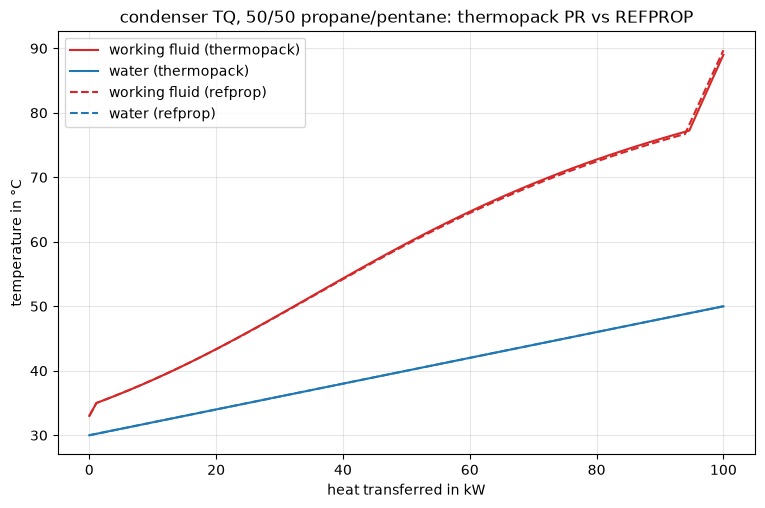

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5.5))

linestyles = {"thermopack": "-", "refprop": "--"}

for engine in ENGINES:
    m = ZeotropicHeatPumpModel(
        fraction=0.5, engine=engine, blend="propane/pentane"
    )
    m.solve_model()
    cd = m.nw.get_comp("condenser")
    ax.plot(
        cd.Q_sections.val, cd.T_hot_sections.val, linestyles[engine],
        color="tab:red", label=f"working fluid ({engine})"
    )
    ax.plot(
        cd.Q_sections.val, cd.T_cold_sections.val, linestyles[engine],
        color="tab:blue", label=f"water ({engine})"
    )

ax.set_xlabel("heat transferred in kW")
ax.set_ylabel("temperature in °C")
ax.grid(alpha=0.3)
ax.legend()
_ = ax.set_title("condenser TQ, 50/50 propane/pentane: thermopack PR vs REFPROP")

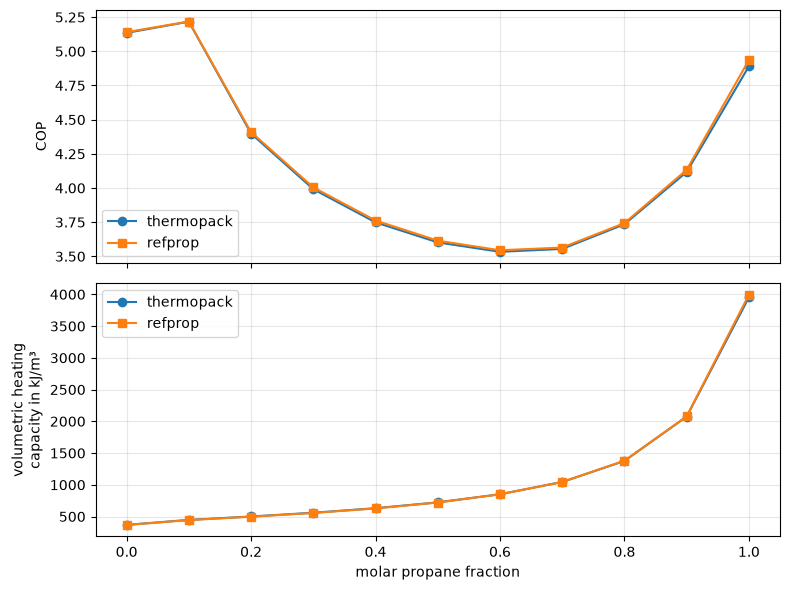

In [8]:
sweep_pentane = sweep_composition("propane/pentane")
_ = plot_sweep(sweep_pentane, "molar propane fraction")

The high glide does not match well with the heat source and the heat sink side
and consequently the COP is much lower compared to the previous mixture.